# Figures S3E and 6F: dynamical metrics

Run cells from top to bottom. Paths and thread counts are centralized in `config/`; embedded plots are retained as visual references from the source analysis.


In [ ]:
# Centralized paths, deterministic seed, and scheduler-aware thread limits.
from pathlib import Path
import sys

repo_root = Path.cwd() if (Path.cwd() / "config" / "paths.py").exists() else Path.cwd().parent
if not (repo_root / "config" / "paths.py").exists():
    raise FileNotFoundError("Run Jupyter from the repository root or notebooks/ directory.")
sys.path.insert(0, str(repo_root))
from config.paths import P38_THREADS, RANDOM_SEED, legacy_path, output_path, p38_path


/home/gonglihao/miniconda3/envs/dynamo_env/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/gonglihao/miniconda3/envs/dynamo_env/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/gonglihao/miniconda3/envs/dynamo_env/lib/python3.8

Loading data from h5ad...

--- Processing WT ---
[WT] 🛠️ Patching missing metadata: adata.uns['pp']['layers_norm_method']
[WT] Calculating velocity confidence...
[WT] Detected confidence keys: ['jaccard_velocity_confidence']
[WT] Target key 'jaccard_velocity_confidence' found.
[WT] Missing physics metrics: ['curl_umap']
[WT] Calculating missing physics metrics...


Calculating 2-D curl: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4694/4694 [00:00<00:00, 12080.62it/s]



--- Processing KO ---
[KO] 🛠️ Patching missing metadata: adata.uns['pp']['layers_norm_method']
[KO] Calculating velocity confidence...
[KO] Detected confidence keys: ['jaccard_velocity_confidence']
[KO] Target key 'jaccard_velocity_confidence' found.
[KO] Missing physics metrics: ['curl_umap']
[KO] Calculating missing physics metrics...


Calculating 2-D curl: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3482/3482 [00:00<00:00, 12996.88it/s]



Final columns available for plotting: ['speed_umap', 'acceleration_umap', 'curvature_umap', 'curl_umap', 'divergence_umap', 'jaccard_velocity_confidence']

Metric                    | Cluster         | P-value    | Sig
----------------------------------------------------------------------
Speed                     | 4 CD115+ CDP    | 7.27e-28   | ***
Speed                     | 1 Iglc3+ pDC    | 7.52e-146   | ***
Acceleration              | 4 CD115+ CDP    | 1.15e-173   | ***
Acceleration              | 7 CD115- CDP    | 8.79e-123   | ***
Acceleration              | 12 pre-pDC      | 4.07e-50   | ***
Acceleration              | 0 Mzb1+ pDC     | 8.77e-213   | ***
Acceleration              | 1 Iglc3+ pDC    | 0.00e+00   | ***
Curvature                 | 4 CD115+ CDP    | 5.15e-21   | ***
Curvature                 | 7 CD115- CDP    | 2.43e-50   | ***
Curvature                 | 12 pre-pDC      | 1.44e-24   | ***
Curvature                 | 0 Mzb1+ pDC     | 3.65e-61   | ***
Curvature   

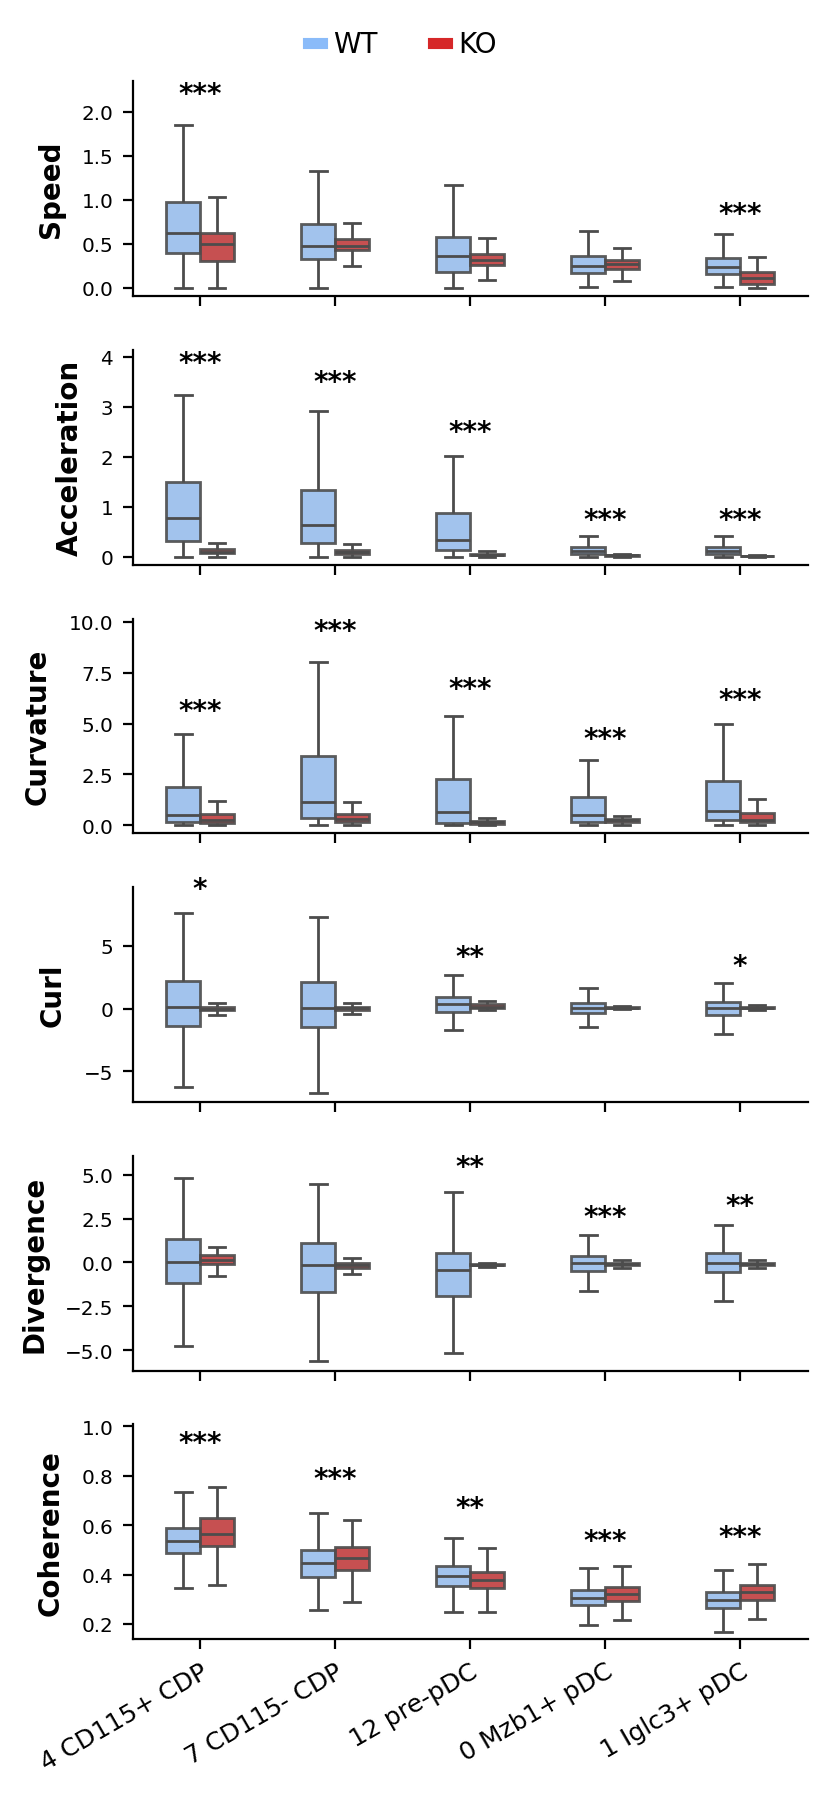

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import dynamo as dyn
from scipy.stats import mannwhitneyu
import os
import warnings

# 忽略烦人的 Numba 警告
warnings.filterwarnings("ignore")

# ===========================
# 1. 配置路径与参数
# ===========================
path_ko = p38_path("20260103-p38/final_results/adata_ko_dynamo_quantified.h5ad")
path_wt = p38_path("20260103-p38/final_results/adata_wt_dynamo_quantified.h5ad")
output_dir = os.path.dirname(path_ko)

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

focus_clusters = [
  "4 CD115+ CDP", "7 CD115- CDP", "12 pre-pDC", "0 Mzb1+ pDC", "1 Iglc3+ pDC"
]

palette = {'WT': '#8abbf9', 'KO': '#D62728'} 

coherence_key = 'jaccard_velocity_confidence' 
metrics = ['speed_umap', 'acceleration_umap', 'curvature_umap', 'curl_umap', 'divergence_umap', coherence_key]
clean_titles = ['Speed', 'Acceleration', 'Curvature', 'Curl', 'Divergence', 'Coherence']

# ===========================
# 2. 强健的数据加载与计算函数 (含修复补丁)
# ===========================
def robust_ensure_metrics(adata, label):
    print(f"\n--- Processing {label} ---")
    
    # =========================================================
    # 修复补丁: 手动注入缺失的元数据 (解决 'layers_norm_method' 报错)
    # =========================================================
    if 'pp' not in adata.uns:
        adata.uns['pp'] = {}
    
    # 检查并补全 layers_norm_method
    # 如果缺失，Dynamo 会以为数据坏了。我们设为 None 或默认值即可骗过检查。
    try:
        _ = adata.uns['pp']['layers_norm_method']
    except KeyError:
        print(f"[{label}] 🛠️ Patching missing metadata: adata.uns['pp']['layers_norm_method']")
        adata.uns['pp']['layers_norm_method'] = None 

    # ---------------------------------------------------------
    # 1. 计算 Coherence (jaccard_velocity_confidence)
    # ---------------------------------------------------------
    # 确保有 neighbors (计算 confidence 的前提)
    if 'connectivities' not in adata.obsp:
        print(f"[{label}] Missing neighbors graph. Recalculating neighbors...")
        try:
            # 使用 PCA 空间计算邻居，这是标准做法
            if 'X_pca' in adata.obsm.keys():
                dyn.tl.neighbors(adata, basis='pca')
            else:
                dyn.tl.neighbors(adata)
        except Exception as e:
            print(f"[{label}] Error calculating neighbors: {e}")

    print(f"[{label}] Calculating velocity confidence...")
    try:
        # 现在有了补丁，这一步应该能跑通了
        dyn.tl.cell_wise_confidence(adata)
    except Exception as e:
        print(f"[{label}] ❌ Error still running cell_wise_confidence: {e}")

    # 智能查找生成的 key 名
    obs_keys = adata.obs.keys()
    confidence_candidates = [k for k in obs_keys if 'confidence' in k]
    print(f"[{label}] Detected confidence keys: {confidence_candidates}")

    if coherence_key in obs_keys:
        print(f"[{label}] Target key '{coherence_key}' found.")
    elif len(confidence_candidates) > 0:
        best_candidate = confidence_candidates[0]
        for k in confidence_candidates:
            if 'jaccard' in k: best_candidate = k # 优先找 jaccard
        
        print(f"[{label}] Mapping '{best_candidate}' -> '{coherence_key}' for plotting.")
        adata.obs[coherence_key] = adata.obs[best_candidate]
    else:
        print(f"[{label}] ⚠️ WARNING: No confidence metric could be calculated!")

    # ---------------------------------------------------------
    # 2. 检查物理场指标
    # ---------------------------------------------------------
    physics_needed = ['curl_umap', 'divergence_umap', 'acceleration_umap', 'curvature_umap', 'speed_umap']
    missing_physics = [k for k in physics_needed if k not in adata.obs.keys()]
    
    if missing_physics:
        print(f"[{label}] Missing physics metrics: {missing_physics}")
        
        vec_fld_exists = 'VecFld_umap' in adata.uns.keys()
        if not vec_fld_exists:
            print(f"[{label}] ⚠️ No Vector Field found! Re-calculating VectorField...")
            try:
                dyn.vf.VectorField(adata, basis='umap') 
            except Exception as e:
                print(f"[{label}] Critical Error: Could not calculate VectorField: {e}")
        
        print(f"[{label}] Calculating missing physics metrics...")
        try:
            if 'curl_umap' in missing_physics: dyn.vf.curl(adata, basis='umap')
            if 'divergence_umap' in missing_physics: dyn.vf.divergence(adata, basis='umap')
            if 'acceleration_umap' in missing_physics: dyn.vf.acceleration(adata, basis='umap')
            if 'curvature_umap' in missing_physics: dyn.vf.curvature(adata, basis='umap')
            if 'speed_umap' in missing_physics: dyn.vf.speed(adata, basis='umap')
        except Exception as e:
            print(f"[{label}] Error calculating physics: {e}")
            
    return adata

# ===========================
# 3. 执行
# ===========================
print("Loading data from h5ad...")
adata_wt = ad.read_h5ad(path_wt)
adata_ko = ad.read_h5ad(path_ko)

adata_wt = robust_ensure_metrics(adata_wt, "WT")
adata_ko = robust_ensure_metrics(adata_ko, "KO")

# ===========================
# 4. 绘图
# ===========================
df_wt = adata_wt.obs.copy(); df_wt['Condition'] = 'WT'
df_ko = adata_ko.obs.copy(); df_ko['Condition'] = 'KO'
df_combined = pd.concat([df_wt, df_ko])

df_plot = df_combined[df_combined['celltype'].isin(focus_clusters)].copy()
df_plot['celltype'] = pd.Categorical(df_plot['celltype'], categories=focus_clusters, ordered=True)

print(f"\nFinal columns available for plotting: {[c for c in metrics if c in df_plot.columns]}")

fig, axes = plt.subplots(6, 1, figsize=(4.5, 9.5), sharex=True)

def get_whisker_top(data):
    if len(data) == 0: return 0
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    return q3 + 1.5 * iqr

print(f"\n{'Metric':<25} | {'Cluster':<15} | {'P-value':<10} | {'Sig'}")
print("-" * 70)

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    if metric not in df_plot.columns:
        ax.text(0.5, 0.5, f"Missing {metric}", ha='center', va='center')
        ax.set_ylabel(clean_titles[i])
        continue

    sns.boxplot(
        data=df_plot, x='celltype', y=metric, hue='Condition', 
        palette=palette, order=focus_clusters, ax=ax, 
        showfliers=False, width=0.5, linewidth=1.0,
        boxprops=dict(alpha=0.9)
    )
    
    y_limit_max = -np.inf 
    for idx, cluster in enumerate(focus_clusters):
        v_wt = df_plot[(df_plot['celltype']==cluster) & (df_plot['Condition']=='WT')][metric].dropna()
        v_ko = df_plot[(df_plot['celltype']==cluster) & (df_plot['Condition']=='KO')][metric].dropna()
        
        top_vis = max(get_whisker_top(v_wt), get_whisker_top(v_ko))
        
        if len(v_wt) > 0 and len(v_ko) > 0:
            stat, p = mannwhitneyu(v_wt, v_ko, alternative='two-sided')
            sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
            
            if sig != "ns":
                print(f"{clean_titles[i]:<25} | {cluster:<15} | {p:.2e}   | {sig}")
                text_y = top_vis + (top_vis * 0.1 if top_vis != 0 else 0.1)
                ax.text(idx, text_y, sig, ha='center', va='bottom', fontsize=10, fontweight='bold')
                if text_y > y_limit_max: y_limit_max = text_y
            else:
                if top_vis > y_limit_max: y_limit_max = top_vis

    if y_limit_max > -np.inf:
        ax.set_ylim(top=y_limit_max * 1.15) 
        
    ax.set_title("") 
    ax.set_ylabel(clean_titles[i], fontsize=10, fontweight='bold', labelpad=6)
    ax.set_xlabel("")
    if ax.get_legend(): ax.get_legend().remove()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=palette['WT'], lw=4, label='WT'),
    Line2D([0], [0], color=palette['KO'], lw=4, label='KO')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.96), 
           ncol=2, fontsize=10, frameon=False)

axes[-1].tick_params(axis='x', rotation=30, labelsize=9)
plt.setp(axes[-1].get_xticklabels(), ha="right", rotation_mode="anchor")
plt.subplots_adjust(left=0.20, right=0.95, top=0.92, bottom=0.10, hspace=0.25)

save_path = os.path.join(output_dir, "Boxplot_Metrics_Fixed_Final.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"\nSaved to: {save_path}")
plt.show()


Metric                    | Cluster         | P-value    | Sig
----------------------------------------------------------------------
Speed                     | 4 CD115+ CDP    | 7.27e-28   | ***
Speed                     | 1 Iglc3+ pDC    | 7.52e-146   | ***
Acceleration              | 4 CD115+ CDP    | 1.15e-173   | ***
Acceleration              | 7 CD115- CDP    | 8.79e-123   | ***
Acceleration              | 12 pre-pDC      | 4.07e-50   | ***
Acceleration              | 0 Mzb1+ pDC     | 8.77e-213   | ***
Acceleration              | 1 Iglc3+ pDC    | 0.00e+00   | ***
Curvature                 | 4 CD115+ CDP    | 5.15e-21   | ***
Curvature                 | 7 CD115- CDP    | 2.43e-50   | ***
Curvature                 | 12 pre-pDC      | 1.44e-24   | ***
Curvature                 | 0 Mzb1+ pDC     | 3.65e-61   | ***
Curvature                 | 1 Iglc3+ pDC    | 5.90e-44   | ***
Curl                      | 4 CD115+ CDP    | 1.61e-02   | *
Curl                      | 12 pre-pDC      

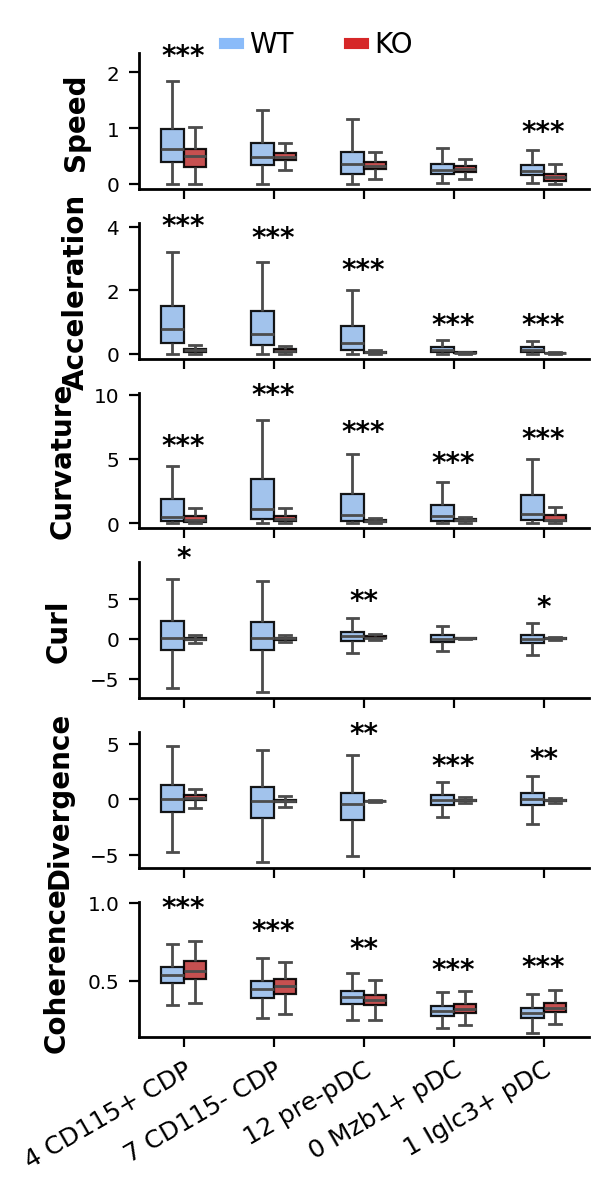

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import numpy as np
import os

# ===========================
# 1. 针对 Adobe Illustrator 的核心优化配置
# ===========================
# 设置 PDF 字体为 Type 42 (TrueType)，确保在 AI 中文字可编辑
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# 推荐使用 Arial 或 Helvetica，AI 对这两种字体支持最好，不易乱码
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# ===========================
# 2. 重新绘图 (必须重新生成 Figure 以应用字体设置)
# ===========================
# 使用与上一个单元格相同的变量
fig, axes = plt.subplots(6, 1, figsize=(3, 6), sharex=True)

# 确保大图背景透明
fig.patch.set_alpha(0)

print(f"\n{'Metric':<25} | {'Cluster':<15} | {'P-value':<10} | {'Sig'}")
print("-" * 70)

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # 设置子图背景透明
    ax.patch.set_alpha(0)
    
    if metric not in df_plot.columns:
        ax.text(0.5, 0.5, f"Missing {metric}", ha='center', va='center')
        ax.set_ylabel(clean_titles[i])
        continue

    # 绘图
    sns.boxplot(
        data=df_plot, x='celltype', y=metric, hue='Condition', 
        palette=palette, order=focus_clusters, ax=ax, 
        showfliers=False, width=0.5, linewidth=1.0,
        boxprops=dict(alpha=0.9, edgecolor='black', linewidth=0.8) # 增加边框清晰度
    )
    
    # 统计检验逻辑 (保持原样)
    y_limit_max = -np.inf 
    for idx, cluster in enumerate(focus_clusters):
        v_wt = df_plot[(df_plot['celltype']==cluster) & (df_plot['Condition']=='WT')][metric].dropna()
        v_ko = df_plot[(df_plot['celltype']==cluster) & (df_plot['Condition']=='KO')][metric].dropna()
        
        # 辅助函数：计算箱线图上边缘
        def get_whisker_top(data):
            if len(data) == 0: return 0
            q1 = data.quantile(0.25); q3 = data.quantile(0.75); iqr = q3 - q1
            return q3 + 1.5 * iqr
            
        top_vis = max(get_whisker_top(v_wt), get_whisker_top(v_ko))
        
        if len(v_wt) > 0 and len(v_ko) > 0:
            stat, p = mannwhitneyu(v_wt, v_ko, alternative='two-sided')
            sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
            
            if sig != "ns":
                print(f"{clean_titles[i]:<25} | {cluster:<15} | {p:.2e}   | {sig}")
                text_y = top_vis + (top_vis * 0.1 if top_vis != 0 else 0.1)
                # 使用 text 保存为文本对象
                ax.text(idx, text_y, sig, ha='center', va='bottom', fontsize=10, fontweight='bold')
                if text_y > y_limit_max: y_limit_max = text_y
            else:
                if top_vis > y_limit_max: y_limit_max = top_vis

    # 调整 Y 轴范围
    if y_limit_max > -np.inf:
        ax.set_ylim(top=y_limit_max * 1.15) 
        
    # 美化
    ax.set_title("") 
    ax.set_ylabel(clean_titles[i], fontsize=10, fontweight='bold', labelpad=6)
    ax.set_xlabel("")
    if ax.get_legend(): ax.get_legend().remove()
    
    # 去除上方和右侧脊柱，并在 AI 中更容易处理线条
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)

# 重绘图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=palette['WT'], lw=4, label='WT'),
    Line2D([0], [0], color=palette['KO'], lw=4, label='KO')
]
# frameon=False 确保图例没有白色背景框
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.96), 
           ncol=2, fontsize=10, frameon=False)

# 调整 X 轴标签
axes[-1].tick_params(axis='x', rotation=30, labelsize=9)
plt.setp(axes[-1].get_xticklabels(), ha="right", rotation_mode="anchor")

plt.subplots_adjust(left=0.20, right=0.95, top=0.92, bottom=0.10, hspace=0.25)

# ===========================
# 3. 保存逻辑 (AI 专用)
# ===========================
ai_save_path = os.path.join(output_dir, "Boxplot_Metrics_AI_Ready.pdf")

# transparent=True 去除背景
# bbox_inches='tight' 裁剪多余空白
plt.savefig(ai_save_path, format='pdf', bbox_inches='tight', transparent=True, dpi=300)

print(f"\n[Success] AI-Ready PDF saved to: {ai_save_path}")
print("Tips for AI: Open PDF -> Right Click -> Release Clipping Mask (Ctrl+Alt+7) if needed.")
plt.show()

In [5]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import dynamo as dyn
import os
from scipy.sparse import issparse
from IPython.display import IFrame, display

# ===========================
# 1. Adobe Illustrator (AI) 兼容性全局配置
# ===========================
# 核心设置：将字体类型设为 42 (TrueType)，防止文字转为路径
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# 字体优先顺序：Arial > Helvetica > 默认无衬线
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']

# 强制去除背景色
matplotlib.rcParams['figure.facecolor'] = 'none'
matplotlib.rcParams['axes.facecolor'] = 'none'
matplotlib.rcParams['savefig.transparent'] = True

# ===========================
# 2. 优化后的绘图函数
# ===========================
def plot_tcf4_visual(save_name="gene_velocity_Tcf4_AI_Ready"):
    # 确定基因名
    target_gene = "Tcf4"
    if target_gene not in adata_wt.var_names: 
        target_gene = "TCF4"
    
    print(f"\nProcessing: {target_gene} ...")

    # 创建画布 (增加 dpi 提高预览清晰度)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=100)
    
    # 确保画布背景透明
    fig.patch.set_alpha(0)
    
    # 确定 Layer
    layer_key = 'velocity_S' if 'velocity_S' in adata_wt.layers.keys() else 'velocity'
    
    # --- 计算统一标尺 (vmin/vmax) ---
    # 这一步是为了让 WT 和 KO 的颜色标尺一致，便于比较
    d_wt = adata_wt[:, target_gene].layers[layer_key]
    if issparse(d_wt): d_wt = d_wt.toarray()
    d_ko = adata_ko[:, target_gene].layers[layer_key]
    if issparse(d_ko): d_ko = d_ko.toarray()
    
    vals = np.concatenate([d_wt.flatten(), d_ko.flatten()])
    # 使用 2% - 98% 分位数去除极端值影响
    vmin_raw, vmax_raw = np.percentile(vals, 2), np.percentile(vals, 98)
    limit = max(abs(vmin_raw), abs(vmax_raw))
    vmin, vmax = -limit, limit

    # --- 绘图 WT ---
    # pointsize=0.05, alpha=0.6 是你指定的参数
    dyn.pl.scatters(adata_wt, basis='umap', color=target_gene, layer=layer_key,
                    ax=axes[0], show_legend='off', 
                    pointsize=0.05, alpha=0.6,
                    vmin=vmin, vmax=vmax, save_show_or_return='return')
    
    axes[0].set_title(f"WT: {target_gene}", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("UMAP1")
    axes[0].set_ylabel("UMAP2")
    axes[0].patch.set_alpha(0) # 确保坐标轴背景透明

    # --- 绘图 KO ---
    dyn.pl.scatters(adata_ko, basis='umap', color=target_gene, layer=layer_key,
                    ax=axes[1], show_legend='off', 
                    pointsize=0.05, alpha=0.6, 
                    vmin=vmin, vmax=vmax, save_show_or_return='return')
    
    axes[1].set_title(f"KO: {target_gene}", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("UMAP1")
    axes[1].set_ylabel("UMAP2")
    axes[1].patch.set_alpha(0) # 确保坐标轴背景透明

    # 标题和布局
    fig.suptitle(f"Key Driver Analysis: {target_gene}", fontsize=16, fontweight='bold', y=0.98)
    
    # 调整布局
    plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.15, wspace=0.3)

    # --- 保存配置 ---
    save_dir = p38_path("20260103-p38/final_results/plots")
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}/{save_name}.pdf"
    
    # 去掉所有脊柱 (Spines) - 如果你想让图更干净，去掉注释即可
    # for ax in axes:
    #     ax.spines['top'].set_visible(False)
    #     ax.spines['right'].set_visible(False)

    print(f"Saving to {save_path} ...")
    
    # !!! 关键保存步骤 !!!
    # transparent=True: 去除背景
    # dpi=300: 保证矢量图中的位图部分（如果有）足够清晰
    # bbox_inches='tight': 自动裁剪多余白边（如果这步报错，可以去掉它）
    try:
        fig.savefig(save_path, format='pdf', transparent=True, bbox_inches='tight')
    except Exception as e:
        print(f"Warning: bbox_inches='tight' failed ({e}), saving without cropping...")
        fig.savefig(save_path, format='pdf', transparent=True)

    print(f"Successfully saved AI-Ready PDF.")
    
    # 关闭图形以释放内存
    plt.close(fig) 
    
    # 在 Notebook 中展示
    print("Displaying generated PDF below:")
    display(IFrame(save_path, width=900, height=500))

# ==============================================================================
# 执行
# ==============================================================================
plot_tcf4_visual()


Processing: Tcf4 ...
|-----------> plotting with basis key=X_umap
|-----------> plotting with basis key=X_umap
Saving to /data3/Group8/gonglihao/项目/p38/20260103-p38/final_results/plots/gene_velocity_Tcf4_AI_Ready.pdf ...
Successfully saved AI-Ready PDF.
Displaying generated PDF below:


Calculating differential velocity for cluster: 4 CD115+ CDP ...
Success! AI-Ready PDF saved to: /data3/Group8/gonglihao/项目/p38/20260103-p38/final_results/Waterfall_Square_AI_Fixed.pdf


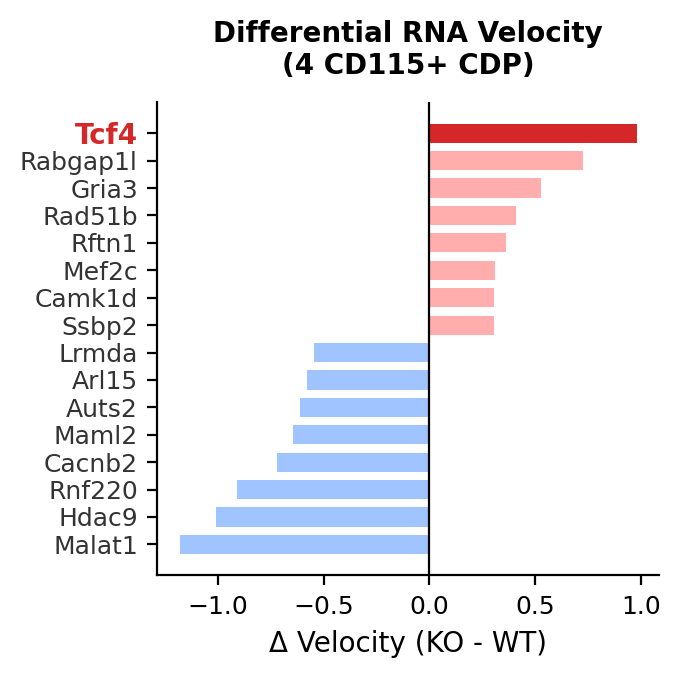

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.sparse import issparse

# ===========================
# 1. Adobe Illustrator (AI) 兼容性配置
# ===========================
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']
matplotlib.rcParams['figure.facecolor'] = 'none'
matplotlib.rcParams['axes.facecolor'] = 'none'
matplotlib.rcParams['savefig.transparent'] = True

# ===========================
# 2. 关键修复：计算基因级 Velocity 差异
# ===========================
# 指定我们要分析的目标亚群 (必须与你之前的列表一致)
target_cluster = "4 CD115+ CDP" 
print(f"Calculating differential velocity for cluster: {target_cluster} ...")

# 确定使用哪个 Layer (优先 velocity_S)
layer_key = 'velocity_S' if 'velocity_S' in adata_wt.layers.keys() else 'velocity'

# 1. 提取 WT 组该亚群的细胞
mask_wt = adata_wt.obs['celltype'] == target_cluster
data_wt = adata_wt[mask_wt].layers[layer_key]
# 计算均值 (处理稀疏矩阵)
if issparse(data_wt):
    mean_wt = np.array(data_wt.mean(axis=0)).flatten()
else:
    mean_wt = np.mean(data_wt, axis=0)

# 2. 提取 KO 组该亚群的细胞
mask_ko = adata_ko.obs['celltype'] == target_cluster
data_ko = adata_ko[mask_ko].layers[layer_key]
if issparse(data_ko):
    mean_ko = np.array(data_ko.mean(axis=0)).flatten()
else:
    mean_ko = np.mean(data_ko, axis=0)

# 3. 构建全新的 gene-level df_plot
# 注意：我们要确保基因名对应。假设 adata_wt 和 adata_ko 的 var_names 是一样的
df_gene_diff = pd.DataFrame({
    'Gene': adata_wt.var_names,
    'WT_Velocity': mean_wt,
    'KO_Velocity': mean_ko
})

# 计算 Delta
df_gene_diff['Delta'] = df_gene_diff['KO_Velocity'] - df_gene_diff['WT_Velocity']

# ===========================
# 3. 筛选绘图数据 (Top/Bottom)
# ===========================
df_sorted = df_gene_diff.sort_values('Delta', ascending=False)

# 筛选 Top 8 增加 + Bottom 8 减少
top_n = 8
bottom_n = 8

top_genes = df_sorted.head(top_n)
bottom_genes = df_sorted.tail(bottom_n)

# 强制包含 Tcf4 (如果它不在前几名的话) 用于展示
if 'Tcf4' not in top_genes['Gene'].values and 'Tcf4' not in bottom_genes['Gene'].values:
    tcf4_row = df_sorted[df_sorted['Gene'] == 'Tcf4']
    if not tcf4_row.empty:
        # 替换掉 Top 最后一名，把 Tcf4 加进去
        top_genes = pd.concat([top_genes.iloc[:-1], tcf4_row])

plot_data = pd.concat([top_genes, bottom_genes])

# ===========================
# 4. 绘图：AI 优化版
# ===========================
fig, ax = plt.subplots(figsize=(3.5, 3.5)) 

# 确保画布透明
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# 颜色逻辑
colors = []
for g, d in zip(plot_data['Gene'], plot_data['Delta']):
    if g == 'Tcf4':
        colors.append('#D62728')      # Tcf4: 深红
    elif d > 0:
        colors.append('#ffadad')      # 增加: 浅红
    else:
        colors.append('#a0c4ff')      # 减少: 浅蓝

# 绘制柱状图
y_pos = np.arange(len(plot_data))
ax.barh(y_pos, plot_data['Delta'], color=colors, height=0.7)

# 反转 Y 轴，让 Top 在上面
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data['Gene'])
ax.invert_yaxis()

# 0 刻度线
ax.axvline(0, color='black', linewidth=0.8)

# --- 样式调整 (AI Friendly) ---
ax.set_title(f"Differential RNA Velocity\n({target_cluster})", fontsize=10, fontweight='bold', pad=10)

# 使用 Unicode Δ 替代 LaTeX $\Delta$，避免字体转曲
ax.set_xlabel("Δ Velocity (KO - WT)", fontsize=10) 

# Y 轴 (基因名) 样式
for i, gene in enumerate(plot_data['Gene']):
    label = ax.get_yticklabels()[i]
    label.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0)) # 去除背景
    
    if gene == 'Tcf4':
        label.set_color('#D62728')
        label.set_fontweight('bold')
        label.set_fontsize(10) 
    else:
        label.set_color('#333333')
        label.set_fontsize(9)

# 坐标轴清理
ax.tick_params(axis='x', labelsize=9)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# 清理所有 Label 的背景
ax.xaxis.label.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0))
ax.yaxis.label.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0))
ax.title.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0))

plt.tight_layout()

# ===========================
# 5. 保存
# ===========================
# 确保 output_dir 存在
if 'output_dir' not in locals(): output_dir = "."

save_path = os.path.join(output_dir, "Waterfall_Square_AI_Fixed.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight', transparent=True)

print(f"Success! AI-Ready PDF saved to: {save_path}")
plt.show()